In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Optional for static 3D plotting
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ensure project root is importable when notebook is opened from notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repository root: {repo_root}")
print("Imports complete.")

from diffsim.data.flumy_generator import FlumyGenerator
from diffsim.data.seismic import (
    generate_rms_from_facies_3d,
    DEFAULT_AI
)

Repository root: /home/tharitt/working/DiffSim
Imports complete.


/home/tharitt/working/DiffSim/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


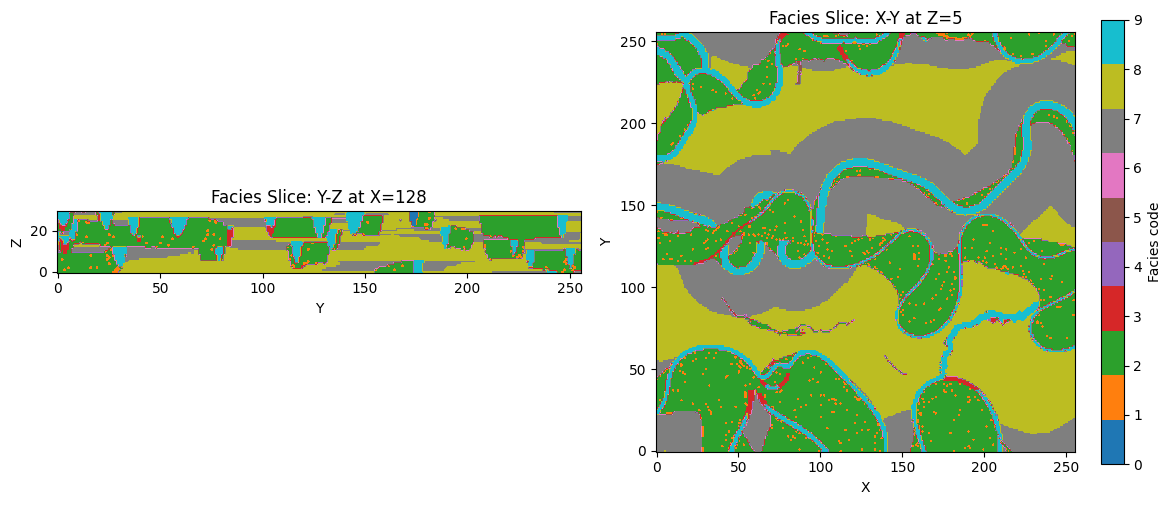

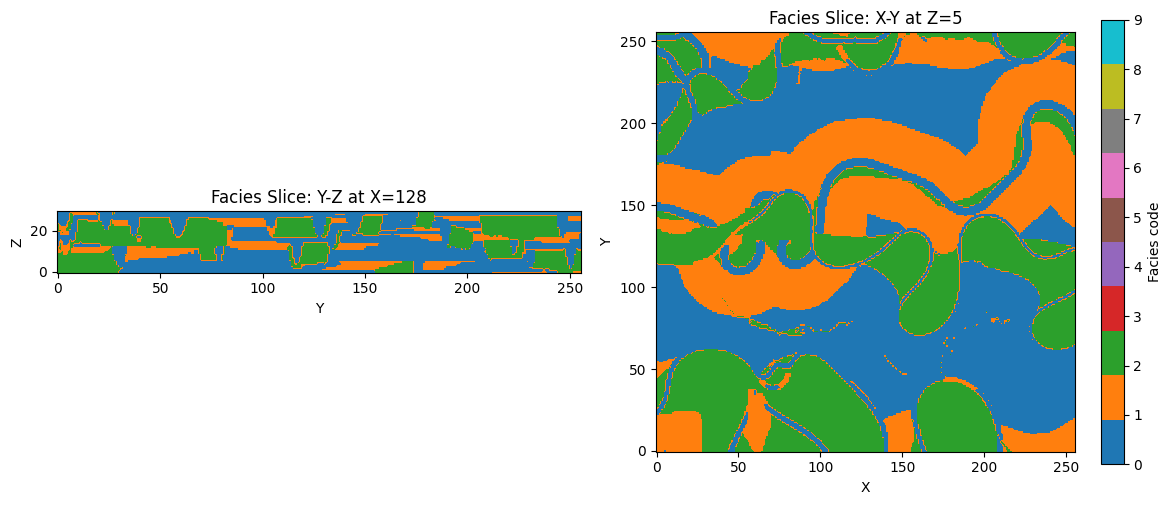

In [2]:

facies_block = np.load("/mnt/sda_data/tharitt/diffsim/data/flumy3d/facies/ng50_isbx80_seed6.npy")
# Slice visualization in two orthogonal planes
#facies_block = FlumyGenerator.reclassify_to_three_facies(facies_block)
nx, ny, nz = facies_block.shape
x_mid = nx // 2
z_mid = nz // 2
z_mid =5

slice_x = facies_block[x_mid, :, :]
slice_z = facies_block[:, :, z_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(slice_x.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
axes[0].set_title(f"Facies Slice: Y-Z at X={x_mid}")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

im1 = axes[1].imshow(slice_z.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
axes[1].set_title(f"Facies Slice: X-Y at Z={z_mid}")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

cbar = fig.colorbar(im1)
cbar.set_label("Facies code")
plt.tight_layout()
plt.show()

facies_block = FlumyGenerator.reclassify_to_three_facies(facies_block)
nx, ny, nz = facies_block.shape
x_mid = nx // 2
z_mid = nz // 2
z_mid =5

slice_x = facies_block[x_mid, :, :]
slice_z = facies_block[:, :, z_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(slice_x.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
axes[0].set_title(f"Facies Slice: Y-Z at X={x_mid}")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

im1 = axes[1].imshow(slice_z.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
axes[1].set_title(f"Facies Slice: X-Y at Z={z_mid}")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

cbar = fig.colorbar(im1)
cbar.set_label("Facies code")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3955903/934442349.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


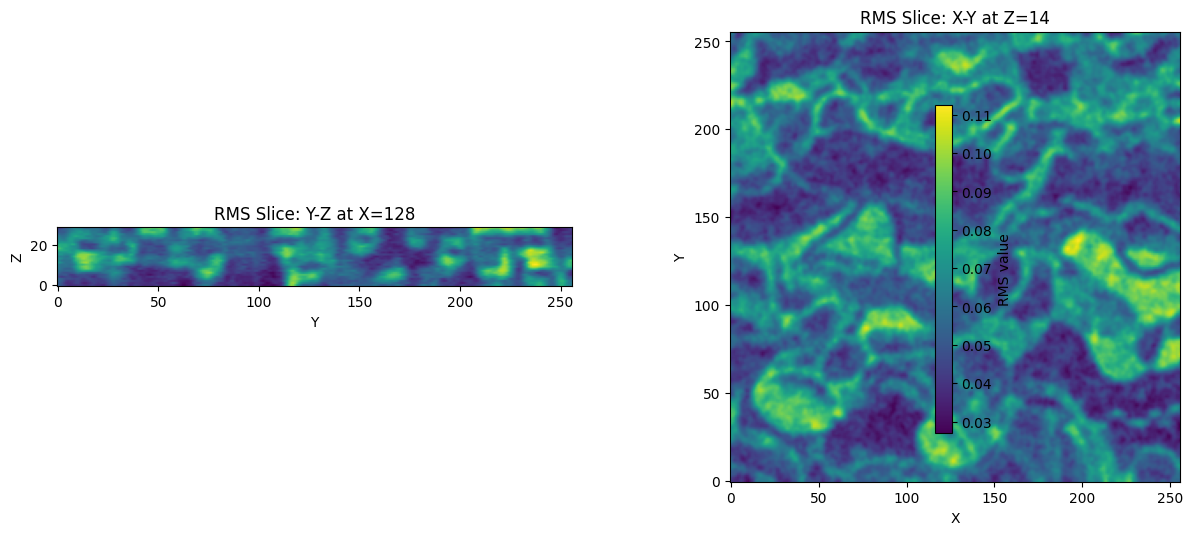

In [21]:
facies_block = np.load("/mnt/sda_data/tharitt/diffsim/data/flumy3d/facies/ng50_isbx80_seed6.npy")
rng = np.random.default_rng(42)
facies_block = FlumyGenerator.reclassify_to_three_facies(facies_block)

rms_block= generate_rms_from_facies_3d(
    facies_block,
    # ai_values=DEFAULT_AI,
    rms_window_half=2,
    noise_level=0.5,
    smooth_sigma=None,  # auto-compute from Fresnel zone radius
    rng=rng,
)

# Slice visualization in two orthogonal plane
nx, ny, nz = rms_block.shape
x_mid = nx // 2
z_mid = nz // 2

slice_x = rms_block[x_mid, :, :]

slice_z = rms_block[:, :, z_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(slice_x.T, origin="lower")
axes[0].set_title(f"RMS Slice: Y-Z at X={x_mid}")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

im1 = axes[1].imshow(slice_z.T, origin="lower") 
axes[1].set_title(f"RMS Slice: X-Y at Z={z_mid}")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("RMS value")
plt.tight_layout()
plt.show()